In [2]:
# %% === Install Required Packages ===
!pip install --quiet \
    pandas \
    numpy \
    matplotlib \
    seaborn \
    scikit-learn \
    torch \
    xgboost \
    joblib \
    tqdm\
    pytorch-tabnet


In [3]:
# %% === Imports ===
import pandas as pd, numpy as np, re, os, time, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, 
    ExtraTreesRegressor, HistGradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge 
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import joblib
from pytorch_tabnet.tab_model import TabNetRegressor
from tqdm import tqdm


In [4]:
# === Config ===
pd.options.mode.chained_assignment = None  # Suppress pandas SettingWithCopyWarning
torch.manual_seed(42)
np.random.seed(42)

DATASET_PATH = "../../../Dataset/Mohamed_Dataset/snapshots/youtube_dataset_snapshot_20251028_144628.csv"


In [5]:
# %% === Load Data ===
data = pd.read_csv(DATASET_PATH, low_memory=False)
data['title'] = data['title'].astype(str)
data = data[~data['title'].str.contains('#', regex=False, na=False)] # Remove rows with '#' in title


In [6]:
# %% === Date Features ===
data['publishedAt'] = pd.to_datetime(data['publishedAt'], errors='coerce')
data['pub_year'] = data['publishedAt'].dt.year
data['pub_month'] = data['publishedAt'].dt.month
data['pub_day'] = data['publishedAt'].dt.day
data['pub_weekday'] = data['publishedAt'].dt.weekday
data['pub_hour'] = data['publishedAt'].dt.hour
data['days_since_first_video'] = (data['publishedAt'] - data['publishedAt'].min()).dt.days


In [7]:
# %% === Duration to Seconds ===
def duration_to_seconds(d):
    if not isinstance(d, str): return 0
    h = int(re.search(r'(\d+)H', d).group(1)) if 'H' in d else 0
    m = int(re.search(r'(\d+)M', d).group(1)) if 'M' in d else 0
    s = int(re.search(r'(\d+)S', d).group(1)) if 'S' in d else 0
    return h * 3600 + m * 60 + s

data['duration_sec'] = data['duration'].apply(duration_to_seconds)

In [8]:
# %% === Clean & Filter ===
key_features = ['viewCount', 'likeCount', 'commentCount', 'pub_year']
data.dropna(subset=key_features, inplace=True)
data.drop_duplicates(subset='video_id', inplace=True, ignore_index=True)

# Keep only videos with reasonable views and published before the most recent day
data = data[
    (data['viewCount'] >= 1000) &
    (data['publishedAt'] <= data['publishedAt'].max() - pd.Timedelta(days=1))
]


In [9]:
# %% === Feature Engineering, Splitting, and Preprocessing ===

# Basic feature creation
data['log_views'] = np.log1p(data['viewCount'])
data['title_length'] = data['title'].str.len().fillna(0)

# Split the dataframe first to prevent data leakage
train_df, temp_df = train_test_split(data, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# --- Channel Statistics (Calculated ONLY on Training Set) ---
if 'channel_id' in train_df.columns:
    ch_stats = train_df.groupby('channel_id')['viewCount'].agg(['mean', 'median', 'std', 'count']).fillna(0)
    ch_stats.columns = [f'channel_{c}_views' for c in ch_stats.columns]
    
    # Merge stats into each dataframe
    train_df = train_df.merge(ch_stats, on='channel_id', how='left')
    val_df = val_df.merge(ch_stats, on='channel_id', how='left')
    test_df = test_df.merge(ch_stats, on='channel_id', how='left')
    
    # Fill missing stats in val/test (for channels not in train) with 0
    for col in ch_stats.columns:
        val_df[col] = val_df[col].fillna(0)
        test_df[col] = test_df[col].fillna(0)
else:
    for c in ['mean', 'median', 'std', 'count']:
        col_name = f'channel_{c}_views'
        train_df[col_name] = 0
        val_df[col_name] = 0
        test_df[col_name] = 0

# --- Categorical & Numeric Feature Preparation ---
numeric_features = [
    'duration_sec','pub_year','pub_month','pub_day','pub_weekday','pub_hour',
    'days_since_first_video',
    'channel_mean_views','channel_median_views','channel_std_views',
    'channel_count_views','title_length'
]
cat_cols = [c for c in ['definition','caption','category'] if c in data.columns]

# One-hot encode categorical features
train_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
val_df = pd.get_dummies(val_df, columns=cat_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)

# Align columns to ensure consistency after encoding
train_cols = train_df.columns
val_df = val_df.reindex(columns=train_cols, fill_value=0)
test_df = test_df.reindex(columns=train_cols, fill_value=0)

# --- Create Final X and y sets ---
encoded_cat_cols = [c for c in train_df.columns if any(col in c for col in cat_cols)]
feature_cols = numeric_features + encoded_cat_cols

X_train = train_df[feature_cols].fillna(0)
y_train = train_df['log_views']

X_val = val_df[feature_cols].fillna(0)
y_val = val_df['log_views']

X_test = test_df[feature_cols].fillna(0)
y_test = test_df['log_views']

# --- Scale Numeric Features ---
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# --- Store Actual Views for Later Analysis ---
actuals = np.expm1(y_test)
actuals_val = np.expm1(y_val)

In [10]:
# %% === Hyperparameter Tuning for RandomForestRegressor (Extended) ===
from sklearn.model_selection import ParameterGrid

# --- Expanded hyperparameter grid ---
param_grid = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True, False]  # whether to use bootstrap samples
}

grid = list(ParameterGrid(param_grid))

results = []
# limit iterations if too many combinations
for params in tqdm(grid[:20], desc="Training RandomForest models"):
    model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    
    # Predict on validation set
    preds_val_log = np.nan_to_num(model.predict(X_val), nan=0)
    preds_val = np.expm1(np.clip(preds_val_log, -20, 20))
    y_val_actual = np.expm1(y_val)
    
    # Metrics
    val_mse = mean_squared_error(y_val_actual, preds_val)
    val_mae = mean_absolute_error(y_val_actual, preds_val)
    val_r2  = r2_score(y_val_actual, preds_val)
    median_error = np.median(np.abs((preds_val - y_val_actual) / (y_val_actual + 1e-9)) * 100)
    
    results.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'min_samples_split': params['min_samples_split'],
        'min_samples_leaf': params['min_samples_leaf'],
        'max_features': params['max_features'],
        'bootstrap': params['bootstrap'],
        'Val_R2': round(val_r2, 4),
        'Val_MAE': round(val_mae, 2),
        'Val_MSE': round(val_mse, 2),
        'Median_Abs_Error (%)': round(median_error, 2),
        'Train_Time(s)': round(train_time, 2)
    })

# Convert to DataFrame and sort by best R2
res_df_val = pd.DataFrame(results).sort_values('Val_R2', ascending=False)

# Display a cleaner table
from IPython.display import display
display(res_df_val.reset_index(drop=True))


Training RandomForest models: 100%|██████████| 20/20 [01:23<00:00,  4.19s/it]


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,Val_R2,Val_MAE,Val_MSE,Median_Abs_Error (%),Train_Time(s)
0,400,None,5,1,sqrt,True,0.7285,470949.58,9.732148e+12,49.31,1.74
1,200,None,5,1,sqrt,True,0.7270,475894.98,9.786495e+12,49.00,0.90
2,600,None,2,1,sqrt,True,0.7268,472378.58,9.793803e+12,48.30,5.15
3,600,None,5,1,sqrt,True,0.7267,470403.15,9.797897e+12,49.20,2.73
4,800,None,2,1,sqrt,True,0.7215,473939.96,9.985087e+12,48.33,5.64
5,800,None,5,1,sqrt,True,0.7213,472259.96,9.991520e+12,49.05,3.66
6,200,None,2,1,sqrt,True,0.7209,475603.13,1.000485e+13,48.46,2.76
7,400,None,2,1,sqrt,True,0.7207,473996.68,1.001381e+13,48.28,4.32
8,600,None,10,1,sqrt,True,0.7015,479061.66,1.070017e+13,49.66,2.49
9,400,None,10,1,sqrt,True,0.6993,480503.13,1.077789e+13,49.60,1.55


In [13]:
# %% === Train & Evaluate All Models (Validation + Median Error, Optimized) ===


# Ensure all features are numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_val = X_val.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)


models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=800,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        min_samples_leaf=3,
        random_state=42
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=1200,
        max_depth=None,
        max_features='sqrt',
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=1500,
        learning_rate=0.03,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42
    ),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        n_jobs=-1
    ),
    "KNN": KNeighborsRegressor(
        n_neighbors=10,
        weights='distance',
        n_jobs=-1
    )
    # "MLP": MLPRegressor(
    #     hidden_layer_sizes=(128, 64),
    #     activation='relu',
    #     solver='adam',
    #     max_iter=2500,
    #     random_state=42
    # )
}

results = []

for name, model in tqdm(models.items(), desc="Training models"):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    # Predict on validation set
    preds_val_log = np.nan_to_num(model.predict(X_val), nan=0)
    preds_val = np.expm1(np.clip(preds_val_log, -20, 20))
    y_val_actual = np.expm1(y_val)

    # Compute metrics
    val_mse = mean_squared_error(y_val_actual, preds_val)
    val_mae = mean_absolute_error(y_val_actual, preds_val)
    val_r2 = r2_score(y_val_actual, preds_val)

    # Compute median error
    errors = np.abs((preds_val - y_val_actual) / (y_val_actual + 1e-9)) * 100
    median_error = np.median(errors)

    results.append({
        'Model': name,
        'Val_MSE': val_mse,
        'Val_MAE': val_mae,
        'Val_R2': val_r2,
        'Median_Abs_Error (%)': median_error,
        'Train_Time': train_time,
        'Model_Instance': model
    })

# Create DataFrame for analysis
res_df_val = pd.DataFrame(results).sort_values('Val_R2', ascending=False)

# Show results including median error
print(res_df_val[['Model', 'Val_R2', 'Val_MAE', 'Val_MSE', 'Median_Abs_Error (%)', 'Train_Time']])


Training models:   0%|          | 0/7 [00:00<?, ?it/s]

Training models: 100%|██████████| 7/7 [00:25<00:00,  3.64s/it]

                  Model    Val_R2        Val_MAE       Val_MSE  \
2            ExtraTrees  0.768094  460623.873147  8.313292e+12   
0          RandomForest  0.721458  473939.956419  9.985087e+12   
5               XGBoost  0.701300  493765.390568  1.070773e+13   
1      GradientBoosting  0.683860  497226.538065  1.133292e+13   
6                   KNN  0.626908  552605.462152  1.337449e+13   
3  HistGradientBoosting  0.617647  528874.370699  1.370650e+13   
4          DecisionTree  0.558667  564849.702572  1.582080e+13   

   Median_Abs_Error (%)  Train_Time  
2             49.589284    4.133739  
0             48.327350    4.404244  
5             50.092273    2.718793  
1             54.341328   10.506227  
6             64.842767    0.009518  
3             54.251288    2.602196  
4             55.799699    0.108543  


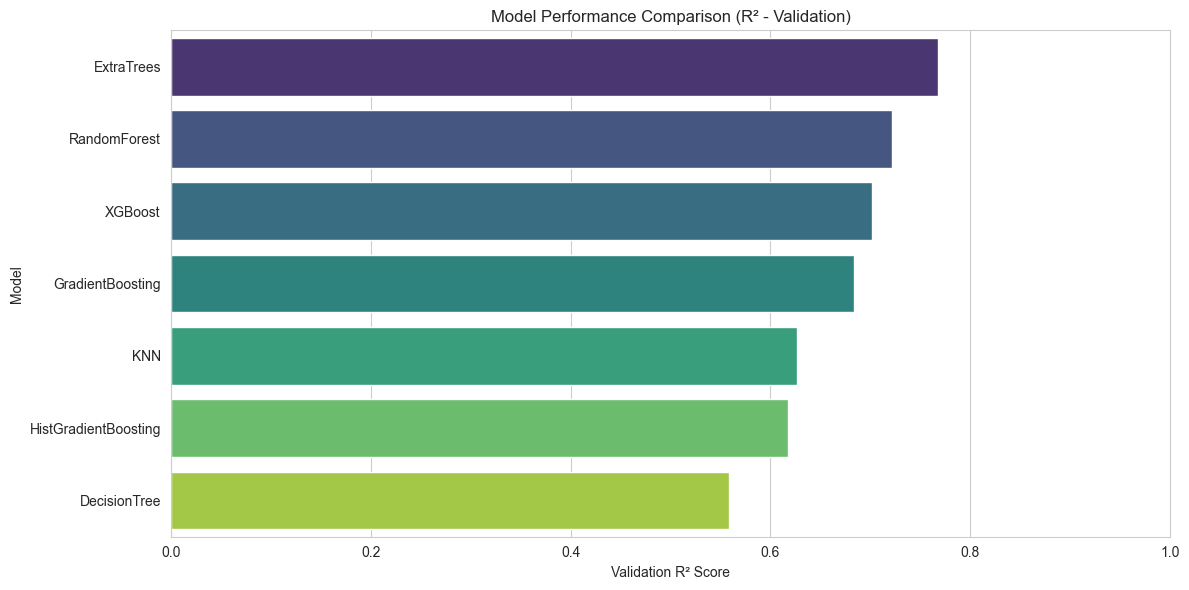

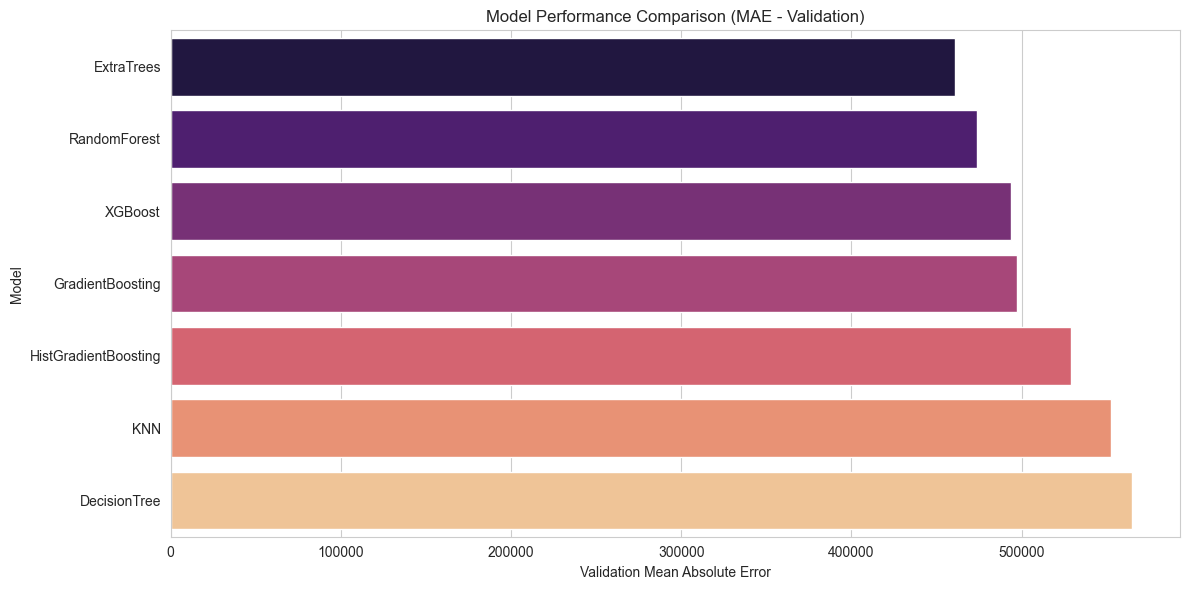

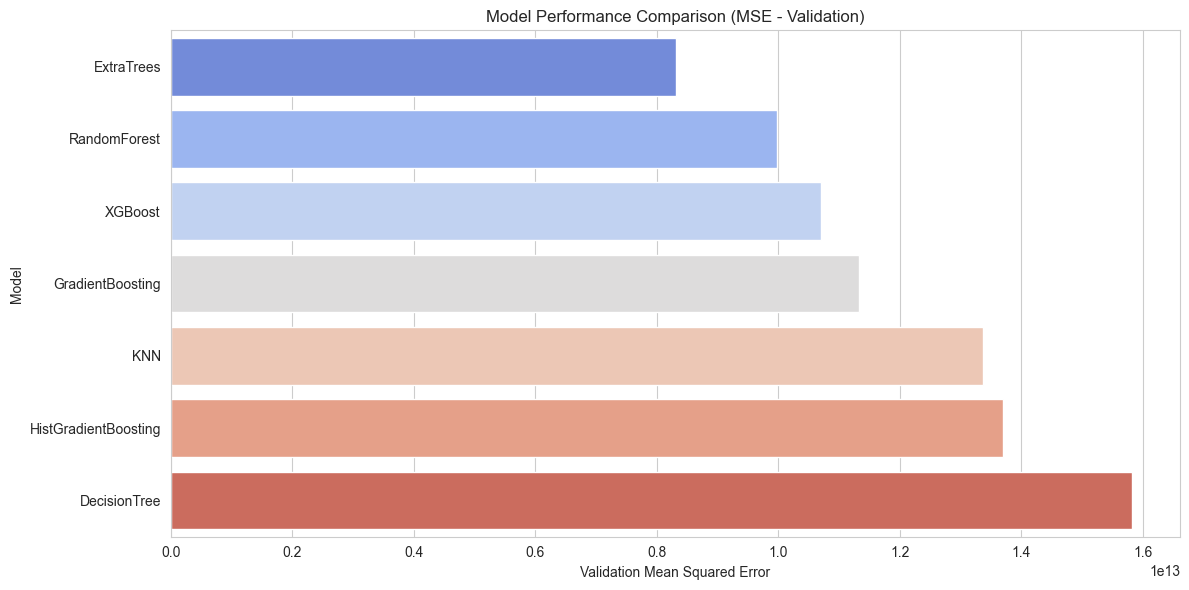

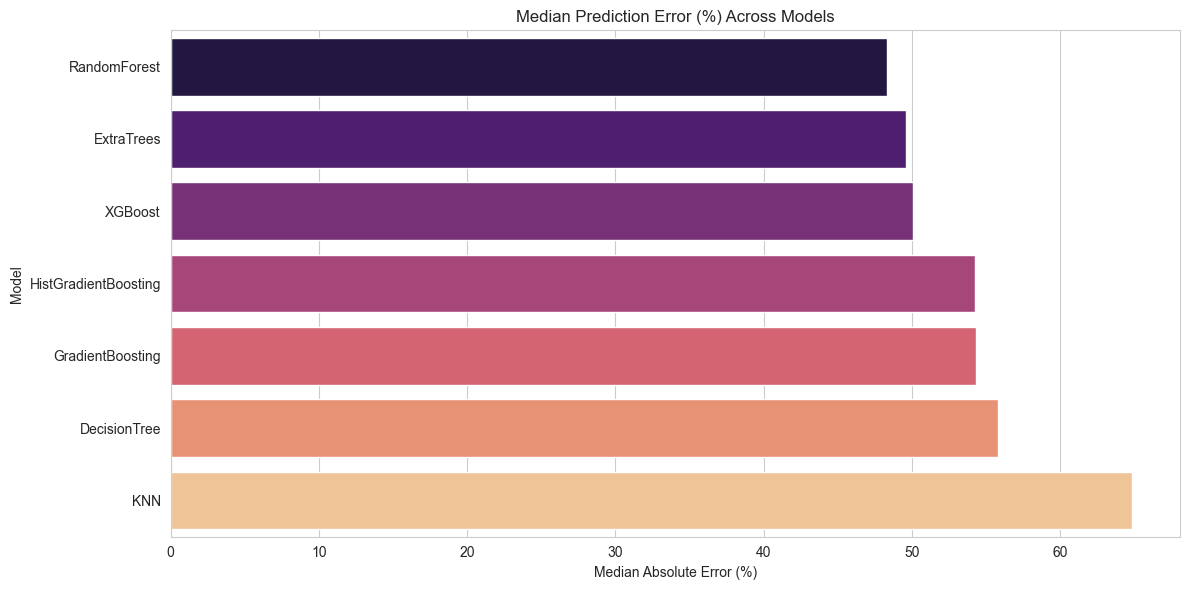

In [14]:
# %% === Visualization: All Models (Validation) ===
# Ensure 'Model' column exists
if 'Model' not in res_df_val.columns:
    res_df_val.rename(columns={'model':'Model'}, inplace=True)

# Set style
sns.set_style("whitegrid")

# Plot Validation R²
plt.figure(figsize=(12,6))
sns.barplot(
    y='Model',
    x='Val_R2',
    data=res_df_val.sort_values('Val_R2', ascending=False),
    palette='viridis',
    hue='Model',
    dodge=False
)
plt.xlabel('Validation R² Score')
plt.title('Model Performance Comparison (R² - Validation)')
plt.xlim(0, 1)
plt.legend([],[], frameon=False)  # hide legend since hue is redundant
plt.tight_layout()
plt.show()

# Plot Validation MAE
plt.figure(figsize=(12,6))
sns.barplot(
    y='Model',
    x='Val_MAE',
    data=res_df_val.sort_values('Val_MAE'),
    palette='magma',
    hue='Model',
    dodge=False
)
plt.xlabel('Validation Mean Absolute Error')
plt.title('Model Performance Comparison (MAE - Validation)')
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

# Plot Validation MSE
plt.figure(figsize=(12,6))
sns.barplot(
    y='Model',
    x='Val_MSE',
    data=res_df_val.sort_values('Val_MSE'),
    palette='coolwarm',
    hue='Model',
    dodge=False
)
plt.xlabel('Validation Mean Squared Error')
plt.title('Model Performance Comparison (MSE - Validation)')
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

# Plot Median Absolute Error
plt.figure(figsize=(12,6))
sns.barplot(
    y='Model',
    x='Median_Abs_Error (%)',
    data=res_df_val.sort_values('Median_Abs_Error (%)'),
    palette='magma',
    hue='Model',
    dodge=False
)
plt.title("Median Prediction Error (%) Across Models")
plt.xlabel("Median Absolute Error (%)")
plt.ylabel("Model")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()


In [15]:
# %% === Final Test Set Evaluation ===
from IPython.display import display

# Make sure y_test_actual is in original scale
y_test_actual = np.expm1(y_test)

# Select top models from validation results (you can change n_top if needed)
n_top = len(res_df_val)  # use all models or choose top N
top_models_eval = res_df_val.head(n_top)

# List to store test results
test_results = []

for _, row in top_models_eval.iterrows():
    model_name = row['Model']
    model = row['Model_Instance']

    # Predict on test set
    preds_test_log = np.nan_to_num(model.predict(X_test), nan=0)
    preds_test = np.expm1(np.clip(preds_test_log, -20, 20))  # avoid extreme log values

    # Compute metrics
    test_r2 = r2_score(y_test_actual, preds_test)
    test_mae = mean_absolute_error(y_test_actual, preds_test)
    test_mse = mean_squared_error(y_test_actual, preds_test)
    median_error = np.median(np.abs((preds_test - y_test_actual) / (y_test_actual + 1e-9)) * 100)

    test_results.append({
        'Model': model_name,
        'Test_R2': test_r2,
        'Test_MAE': test_mae,
        'Test_MSE': test_mse,
        'Median_Abs_Error (%)': median_error
    })

# Create DataFrame for nice display
test_results_df = pd.DataFrame(test_results).sort_values('Test_R2', ascending=False)
display(test_results_df)

# Optional: print summary
print("\n=== Test Set Evaluation Summary ===\n")
for _, row in test_results_df.iterrows():
    print(f"Model: {row['Model']}")
    print(f"  Test R²: {row['Test_R2']:.4f}")
    print(f"  Test MAE: {row['Test_MAE']:.2f}")
    print(f"  Test MSE: {row['Test_MSE']:.2f}")
    print(f"  Median Absolute Error (%): {row['Median_Abs_Error (%)']:.2f}%\n")


,Model,Test_R2,Test_MAE,Test_MSE,Median_Abs_Error (%)
0,ExtraTrees,0.714645,565216.018409,1.273018e+13,49.360473
1,RandomForest,0.705716,562170.773436,1.312852e+13,48.297321
3,GradientBoosting,0.691279,581334.428949,1.377255e+13,53.470657
2,XGBoost,0.677396,592463.324982,1.439189e+13,49.155197
6,DecisionTree,0.628534,660176.961965,1.657169e+13,55.389617
5,HistGradientBoosting,0.616045,644757.040389,1.712889e+13,53.032819
4,KNN,0.603917,668196.757456,1.766992e+13,65.067060



=== Test Set Evaluation Summary ===

Model: ExtraTrees
  Test R²: 0.7146
  Test MAE: 565216.02
  Test MSE: 12730180982275.40
  Median Absolute Error (%): 49.36%

Model: RandomForest
  Test R²: 0.7057
  Test MAE: 562170.77
  Test MSE: 13128517424905.52
  Median Absolute Error (%): 48.30%

Model: GradientBoosting
  Test R²: 0.6913
  Test MAE: 581334.43
  Test MSE: 13772550268375.64
  Median Absolute Error (%): 53.47%

Model: XGBoost
  Test R²: 0.6774
  Test MAE: 592463.32
  Test MSE: 14391894018513.64
  Median Absolute Error (%): 49.16%

Model: DecisionTree
  Test R²: 0.6285
  Test MAE: 660176.96
  Test MSE: 16571692291319.83
  Median Absolute Error (%): 55.39%

Model: HistGradientBoosting
  Test R²: 0.6160
  Test MAE: 644757.04
  Test MSE: 17128888444038.03
  Median Absolute Error (%): 53.03%

Model: KNN
  Test R²: 0.6039
  Test MAE: 668196.76
  Test MSE: 17669917220365.90
  Median Absolute Error (%): 65.07%

